In [ ]:
import time

import matplotlib.pyplot as plt

from path import findPath
from sokoban import findSolution

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [29]:
# seems time performance is pretty all-over-the-place and inconsistent

env = [
  [0, 0, 0, 0],
  [0, 1, 0, 0],
  [2, 1, 0, 0],
  [0, 1, 0, 0],
]

steps = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
times = []

for step in steps:
  t1 = time.time()
  positions = findPath(env, 6, step)
  t2 = time.time()
  
  dt = t2 - t1
  
  times.append(dt)
  print(f'step={step}: {dt}s')
  print(f'step={step} actual number of steps: {len(positions)}')

step=5: 0.023391008377075195s
step=5 actual number of steps: 6
step=10: 0.04050469398498535s
step=10 actual number of steps: 10
step=15: 0.09037280082702637s
step=15 actual number of steps: 16
step=20: 0.13896417617797852s
step=20 actual number of steps: 21
step=25: 0.15897822380065918s
step=25 actual number of steps: 6
step=30: 0.2732408046722412s
step=30 actual number of steps: 23
step=35: 0.3251371383666992s
step=35 actual number of steps: 35
step=40: 0.5939779281616211s
step=40 actual number of steps: 40
step=45: 0.6792290210723877s
step=45 actual number of steps: 24
step=50: 0.747373104095459s
step=50 actual number of steps: 43


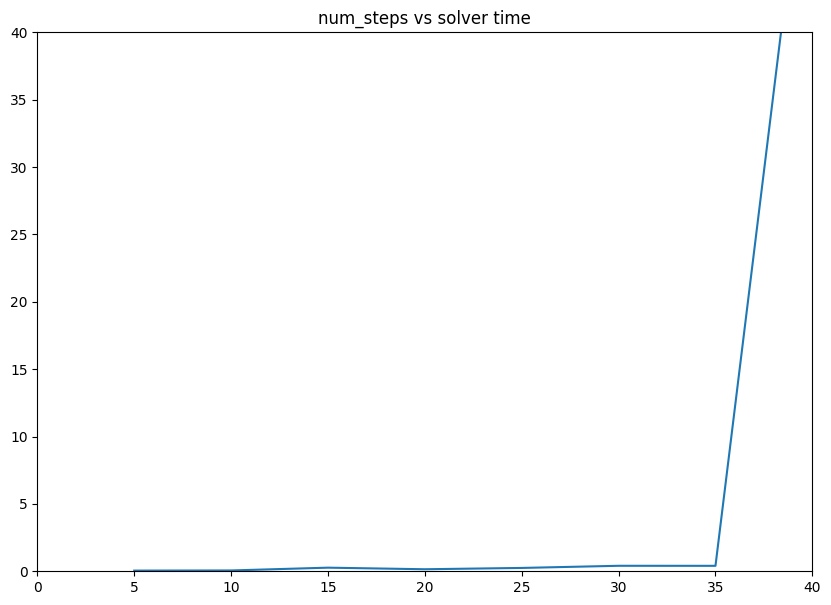

In [22]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(steps, times)
ax.set_title('num_steps vs solver time')
ax.set_xbound(0, 40)
ax.set_ybound(0, 40)

In [34]:
env = [
    [0, 3, 0, 0],
    [3, 3, 0, 0],
    [0, 0, 3, 0],
    [0, 1, 2, 1],
]

steps = [3, 6, 9, 12, 15, 18]
times = []

for step in steps:
  t1 = time.time()
  positions = findSolution(env, 0, 3)
  t2 = time.time()
  
  dt = t2 - t1
  
  times.append(dt)
  print(f'step={step}: {dt}s')
  print(f'step={step} actual number of steps: {len(positions)}')

step=3: 5.733136892318726s
step=3 actual number of steps: 274
step=6: 4.398377895355225s
step=6 actual number of steps: 274
step=9: 4.595483064651489s
step=9 actual number of steps: 274
step=12: 5.193277835845947s
step=12 actual number of steps: 274
step=15: 5.974179029464722s
step=15 actual number of steps: 274
step=18: 5.78186297416687s
step=18 actual number of steps: 274


Visualization

In [57]:
import PIL
import os

baba_sprite = PIL.Image.open('assets/baba.png')
box_sprite = PIL.Image.open('assets/box.png')
wall_sprite = PIL.Image.open('assets/wall.png')
goal_sprite = PIL.Image.open('assets/goal.png')

In [66]:

env = [
    [0, 3, 0],
    [3, 3, 2],
    [0, 0, 0],
]
n = len(env)

model = findSolution(env, 0, 1)

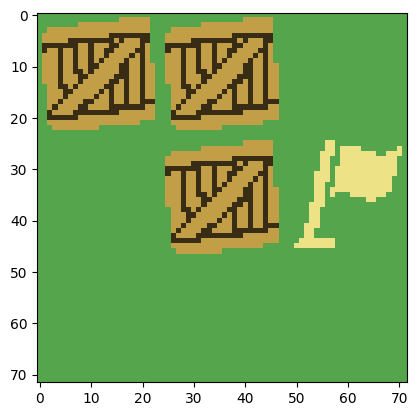

In [67]:
env_z3 = None

for decl in model.decls():
  if decl.name() == 'env_1':
    env_z3 = model[decl]

level = PIL.Image.new('RGB', size=(24*n, 24*n), color='#54a54b')

for i in range(n**2):
  x = i % n
  y = i // n
  
  e = model.evaluate(env_z3[i]).as_long()
  img = None
  
  if e != 0:
    if e == 1:
      img = wall_sprite
    elif e == 2:
      img = goal_sprite
    elif e == 3:
      img = box_sprite
    
    level.paste(img, box=(24*x, 24*y))

plt.imshow(level)